In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [11]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


<Axes: xlabel='month'>

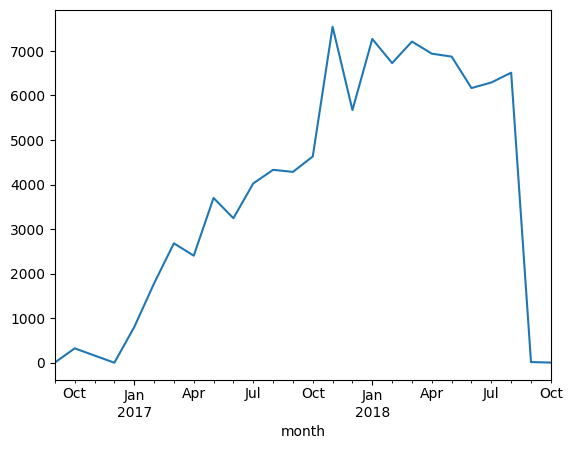

In [14]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = df.groupby('month').size()

monthly_orders.plot()

In [9]:
df = pd.read_csv('olist_orders_dataset.csv', sep=',')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [16]:
customers = pd.read_csv('olist_customers_dataset.csv')

In [17]:
df_merged = df.merge(customers, on='customer_id', how='left')

In [18]:
df_merged['customer_state'].value_counts().head(10)

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [19]:
df_merged['delivery_time'] = df_merged['order_delivered_customer_date'] - df_merged['order_purchase_timestamp']

In [20]:
df_merged[['delivery_time']].head()

,delivery_time
0,8 days 10:28:40
1,13 days 18:46:08
2,9 days 09:27:40
3,13 days 05:00:36
4,2 days 20:58:23


In [21]:
df_merged['delivery_days'] = df_merged['delivery_time'].dt.days

In [22]:
df_merged['delivery_days'].describe()

,delivery_days
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [23]:
df_merged.sort_values(by='delivery_days', ascending=False).head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_time,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,75683a92331068e2d281b11a7866ba44,delivered,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,2017-02,4a2519b6991378f6f2ce5ed22d308f03,29890,montanha,ES,209 days 15:05:12,209.0
55619,1b3190b2dfa9d789e1f14c05b647a14a,d306426abe5fca15e54b645e4462dc7b,delivered,2018-02-23 14:57:35,2018-02-23 15:16:14,2018-02-26 18:49:07,2018-09-19 23:24:07,2018-03-15,2018-02,eb21169c3153a2b507fc7e76d561ff14,22723,rio de janeiro,RJ,208 days 08:26:32,208.0
61610,440d0d17af552815d15a9e41abe49359,7815125148cfa1e8c7fee1ff7974f16c,delivered,2017-03-07 23:59:51,2017-03-09 01:11:33,2017-03-15 13:00:08,2017-09-19 15:12:50,2017-04-07,2017-03,f0785d41d416fa827f24c4b95d066b69,66813,belem,PA,195 days 15:12:59,195.0
70307,2fb597c2f772eca01b1f5c561bf6cc7b,217906bc11a32c1e470eb7e08584894b,delivered,2017-03-08 18:09:02,2017-03-08 18:09:02,2017-03-13 08:54:02,2017-09-19 14:33:17,2017-04-17,2017-03,c6c0b794d3e4eb69cd85d1438a0db26e,64023,teresina,PI,194 days 20:24:15,194.0
38509,0f4519c5f1c541ddec9f21b3bddd533a,1a8a4a30dc296976717f44e7801fdeef,delivered,2017-03-09 13:26:57,2017-03-09 13:26:57,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11,2017-03,4df2d7257a7463e2d7a98a5b08cb92fc,64013,teresina,PI,194 days 01:11:24,194.0
89130,285ab9426d6982034523a855f55a885e,9cf2c3fa2632cee748e1a59ca9d09b21,delivered,2017-03-08 22:47:40,2017-03-08 22:47:40,2017-03-09 08:53:20,2017-09-19 14:00:04,2017-04-06,2017-03,3c2564d42f7ddd8b7576f0dd9cb1b4c5,49400,lagarto,SE,194 days 15:12:24,194.0
11399,47b40429ed8cce3aee9199792275433f,cb2caaaead400c97350c37a3fc536867,delivered,2018-01-03 09:44:01,2018-01-03 10:31:15,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,2018-01,4cb8ad9a4554099db7d70c13d0dae906,13327,salto,SP,191 days 11:07:30,191.0
81401,2fe324febf907e3ea3f2aa9650869fa5,65b14237885b3972ebec28c0f7dd2220,delivered,2017-03-13 20:17:10,2017-03-13 20:17:10,2017-03-17 07:23:53,2017-09-19 17:00:07,2017-04-05,2017-03,78d26ae26b5bb9cb398edc7384d3c15f,13142,paulinia,SP,189 days 20:42:57,189.0
54480,2d7561026d542c8dbd8f0daeadf67a43,8199345f57c6d1cbe9701f92481beb8d,delivered,2017-03-15 11:24:27,2017-03-15 11:24:27,2017-03-16 09:29:16,2017-09-19 14:38:18,2017-04-13,2017-03,186a453a38d349c487ccbf472b31fb39,49037,aracaju,SE,188 days 03:13:51,188.0
68769,c27815f7e3dd0b926b58552628481575,f85e9ec0719b16dc4dd0edd438793553,delivered,2017-03-15 23:23:17,2017-03-15 23:23:17,2017-03-21 14:50:25,2017-09-19 17:14:25,2017-04-10,2017-03,e7834c7e017fb854ac65189a66c33132,38170,perdizes,MG,187 days 17:51:08,187.0


In [24]:
df_merged.groupby('customer_state')['delivery_days'].mean().sort_values(ascending=False).head(10)

,delivery_days
customer_state,
RR,28.975610
AP,26.731343
AM,25.986207
AL,24.040302
PA,23.316068
MA,21.117155
SE,21.029851
CE,20.817826
AC,20.637500
